## 0. Install & Imports

In [ ]:
!pip install -q timm xgboost lightgbm scikit-learn opencv-python tqdm matplotlib seaborn scipy scikit-image

In [ ]:
import os, random, warnings, copy, gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CHALLENGE_DIR  = "/content/drive/MyDrive/DCU 2026 ML challenge"
IMAGES_DIR     = os.path.join(CHALLENGE_DIR, "images_final_sample")

# Checkpoint directory — all fold weights + probs saved here
CKPT_DIR = os.path.join(CHALLENGE_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

assert os.path.isdir(CHALLENGE_DIR), f"Not found: {CHALLENGE_DIR}"
assert os.path.isdir(IMAGES_DIR),    f"Not found: {IMAGES_DIR}"

imgs = [f for f in os.listdir(IMAGES_DIR) if not f.startswith('.')]
print(f"Images dir    : {IMAGES_DIR}")
print(f"Image count   : {len(imgs)}")
print(f"Checkpoint dir: {CKPT_DIR}")

Mounted at /content/drive
Images dir    : /content/drive/MyDrive/DCU 2026 ML challenge/images_final_sample
Image count   : 6888
Checkpoint dir: /content/drive/MyDrive/DCU 2026 ML challenge/checkpoints


## 2. Load & Validate CSVs

In [ ]:
train_df = pd.read_csv(os.path.join(CHALLENGE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(CHALLENGE_DIR, "test.csv"))

train_df['label'] = train_df['ground_truth'].astype(int)

def resolve_path(image_id):
    for ext in ['', '.jpg', '.jpeg', '.png', '.webp']:
        p = os.path.join(IMAGES_DIR, str(image_id) + ext)
        if os.path.exists(p): return p
    return None

train_df['path'] = train_df['image_id'].apply(resolve_path)
test_df['path']  = test_df['image_id'].apply(resolve_path)

train_df_valid = train_df.dropna(subset=['path']).reset_index(drop=True)
test_df_valid  = test_df.dropna(subset=['path']).reset_index(drop=True)

print(f"Train : {len(train_df_valid):,}  |  Test : {len(test_df_valid):,}")
vc = train_df_valid['label'].value_counts().rename({0:'authentic', 1:'ai_generated'})
print(f"\nLabel distribution:\n{vc}")
print(f"Class balance : {vc.min()/vc.max():.3f}  (1.0 = perfect)")

y_train = train_df_valid['label'].values

Train : 4,800  |  Test : 2,058

Label distribution:
label
authentic       2485
ai_generated    2315
Name: count, dtype: int64
Class balance : 0.932  (1.0 = perfect)


## 3. EDA — Sample Grid & Size Distribution

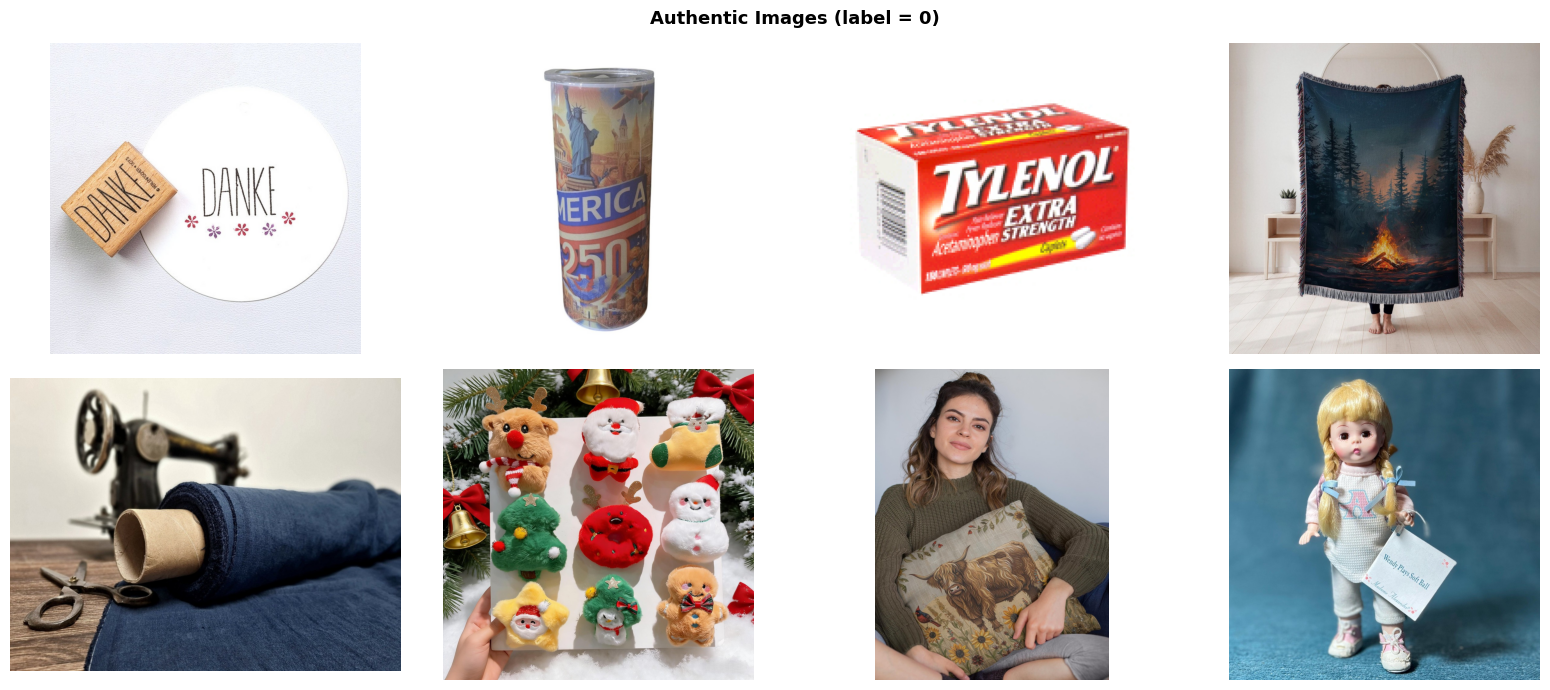

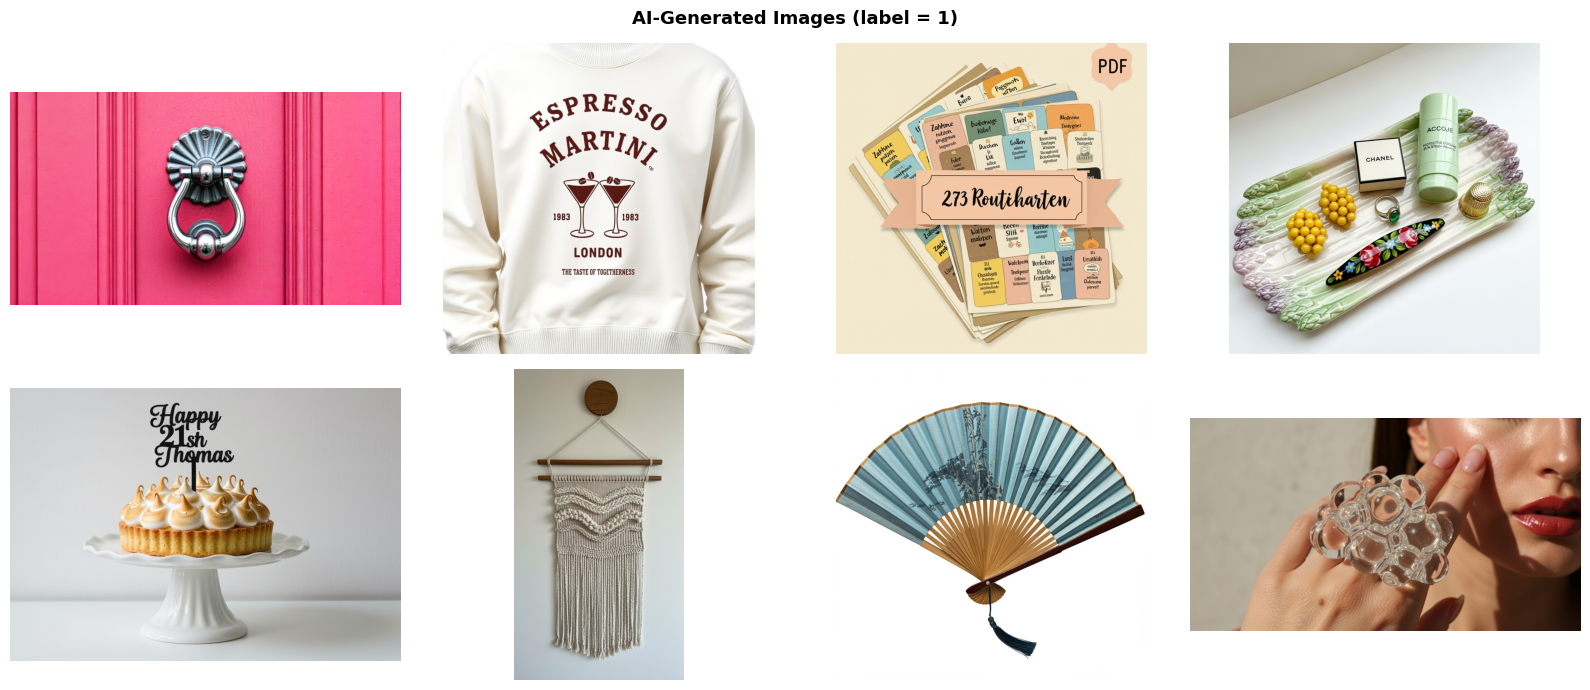

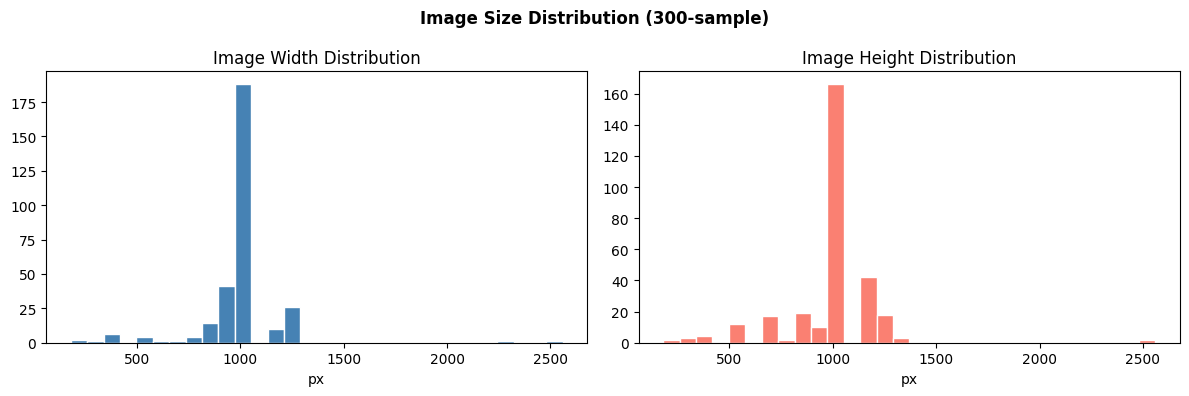

Median size: 1024x1024 px


In [ ]:
def show_grid(df, label_val, title, n=8):
    subset = df[df['label'] == label_val].sample(
        min(n, (df['label']==label_val).sum()), random_state=SEED)
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (_, row) in zip(axes.flat, subset.iterrows()):
        img = cv2.imread(row['path'])
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_grid(train_df_valid, 0, 'Authentic Images (label = 0)')
show_grid(train_df_valid, 1, 'AI-Generated Images (label = 1)')

heights, widths = [], []
for p in train_df_valid['path'].sample(min(300, len(train_df_valid)), random_state=SEED):
    img = cv2.imread(p)
    if img is not None:
        heights.append(img.shape[0]); widths.append(img.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution'); axes[0].set_xlabel('px')
axes[1].hist(heights, bins=30, color='salmon',   edgecolor='white')
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('px')
plt.suptitle('Image Size Distribution (300-sample)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Median size: {int(np.median(widths))}x{int(np.median(heights))} px")

## 4. Handcrafted Feature Extraction



In [ ]:
def extract_features(img_bgr, size=224):
    img  = cv2.resize(img_bgr, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    feats = []

    # 1. FFT radial band energy (9)
    fshift    = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.log1p(np.abs(fshift))
    h, w      = magnitude.shape
    cy, cx    = h // 2, w // 2
    Y, X      = np.ogrid[:h, :w]
    dist      = np.sqrt((Y - cy)**2 + (X - cx)**2)
    for r1, r2 in [(0,15),(15,40),(40,80),(80,120),(120,160)]:
        mask = (dist >= r1) & (dist < r2)
        feats.append(float(magnitude[mask].mean()) if mask.any() else 0.0)
    feats.append(float(magnitude[dist > 90].mean()))
    feats.append(float(magnitude[dist > 90].std()))
    feats.append(float(magnitude[dist < 10].mean()))

    # 2. Laplacian noise residual (4)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    feats += [float(lap.var()), float(lap.mean()),
              float(np.abs(lap).mean()), float(np.percentile(np.abs(lap), 95))]

    # 3. Per-channel colour stats + histogram RGB (66)
    for c in range(3):
        ch = rgb[:, :, c]
        feats += [float(ch.mean()), float(ch.std()), float(ch.min()), float(ch.max()),
                  float(np.percentile(ch, 25)), float(np.percentile(ch, 75))]
        hist, _ = np.histogram(ch, bins=16, range=(0, 1))
        feats  += (hist / (hist.sum() + 1e-8)).tolist()

    # 4. Blockwise texture variance (6)
    block    = 32
    var_list = [gray[y:y+block, x:x+block].var()
                for y in range(0, size, block) for x in range(0, size, block)]
    feats += [float(np.mean(var_list)), float(np.std(var_list)),
              float(np.max(var_list)),  float(np.min(var_list)),
              float(np.percentile(var_list, 25)), float(np.percentile(var_list, 75))]

    # 5. Canny edge density (2)
    edges = cv2.Canny(img.astype(np.uint8), 50, 150)
    feats += [float(edges.mean()), float(edges.std())]

    # 6. HSV stats (12)
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32) / 255.0
    for c in range(3):
        ch = hsv[:, :, c]
        feats += [float(ch.mean()), float(ch.std()),
                  float(np.percentile(ch, 25)), float(np.percentile(ch, 75))]

    # 7. DCT high-freq energy (3)
    gray_u8  = gray.astype(np.uint8)
    dct_vals = [float(np.abs(cv2.dct(gray_u8[y:y+8, x:x+8].astype(np.float32))[4:, 4:]).mean())
                for y in range(0, size-8, 8) for x in range(0, size-8, 8)]
    feats += [float(np.mean(dct_vals)), float(np.std(dct_vals)), float(np.max(dct_vals))]

    # 8. Saturation skew/kurtosis (2)
    sat = hsv[:, :, 1].flatten()
    feats += [float(skew(sat)), float(kurtosis(sat))]

    # 9. Inter-channel correlation (3)
    r = rgb[:, :, 0].flatten()
    g = rgb[:, :, 1].flatten()
    b = rgb[:, :, 2].flatten()
    feats += [float(np.corrcoef(r, g)[0, 1]),
              float(np.corrcoef(r, b)[0, 1]),
              float(np.corrcoef(g, b)[0, 1])]

    # 10. Noise floor via median-filter residual (2)
    denoised = cv2.medianBlur(gray.astype(np.uint8), 3).astype(np.float32)
    noise    = gray - denoised
    feats += [float(noise.std()), float(np.abs(noise).mean())]

    # 11. FFT hi/lo energy ratio (1)
    hi_energy = float(magnitude[dist > 60].mean())
    lo_energy = float(magnitude[dist < 20].mean())
    feats.append(hi_energy / (lo_energy + 1e-8))

    # 12. GLCM texture features (20)
    gray_q  = (gray / 8).astype(np.uint8).clip(0, 31)
    glcm    = graycomatrix(gray_q, distances=[1, 3], angles=[0, np.pi/4],
                           levels=32, symmetric=True, normed=True)
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop).flatten()
        feats += vals.tolist()

    # 13. LBP histogram (10)
    lbp      = local_binary_pattern(gray.astype(np.uint8), P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10))
    feats   += (lbp_hist / (lbp_hist.sum() + 1e-8)).tolist()

    feats = [0.0 if (np.isnan(f) or np.isinf(f)) else f for f in feats]
    return feats


def extract_all(df, desc='Extracting'):
    feats = []
    for p in tqdm(df['path'], desc=desc):
        img = cv2.imread(p)
        if img is None:
            img = np.zeros((224, 224, 3), np.uint8)
        feats.append(extract_features(img))
    return np.array(feats, dtype=np.float32)


# Define checkpoint paths for handcrafted features
HAND_TRAIN_CKPT = os.path.join(CKPT_DIR, "X_hand_train.npy")
HAND_TEST_CKPT  = os.path.join(CKPT_DIR, "X_hand_test.npy")

# Check and load/extract for training features
if os.path.exists(HAND_TRAIN_CKPT):
    print(f"[CHECKPOINT] Loading X_hand_train from {HAND_TRAIN_CKPT}...")
    X_hand_train = np.load(HAND_TRAIN_CKPT)
else:
    print("Extracting TRAIN features ...")
    X_hand_train = extract_all(train_df_valid, 'Train')
    np.save(HAND_TRAIN_CKPT, X_hand_train)
    print(f"[CHECKPOINT] X_hand_train saved to {HAND_TRAIN_CKPT}")

# Check and load/extract for test features
if os.path.exists(HAND_TEST_CKPT):
    print(f"[CHECKPOINT] Loading X_hand_test from {HAND_TEST_CKPT}...")
    X_hand_test = np.load(HAND_TEST_CKPT)
else:
    print("Extracting TEST features ...")
    X_hand_test  = extract_all(test_df_valid,  'Test')
    np.save(HAND_TEST_CKPT, X_hand_test)
    print(f"[CHECKPOINT] X_hand_test saved to {HAND_TEST_CKPT}")

X_hand_train = np.nan_to_num(X_hand_train, nan=0.0, posinf=0.0, neginf=0.0)
X_hand_test  = np.nan_to_num(X_hand_test,  nan=0.0, posinf=0.0, neginf=0.0)

print(f"Train feature matrix : {X_hand_train.shape}")
print(f"Test  feature matrix : {X_hand_test.shape}")

Extracting TRAIN features ...


Train: 100%|██████████| 4800/4800 [06:16<00:00, 12.76it/s]


[CHECKPOINT] X_hand_train saved to /content/drive/MyDrive/DCU 2026 ML challenge/checkpoints/X_hand_train.npy
Extracting TEST features ...


Test: 100%|██████████| 2058/2058 [03:01<00:00, 11.34it/s]

[CHECKPOINT] X_hand_test saved to /content/drive/MyDrive/DCU 2026 ML challenge/checkpoints/X_hand_test.npy
Train feature matrix : (4800, 139)
Test  feature matrix : (2058, 139)


## 5. Baseline — Random Forest

Random Forest Baseline (80/20 split) — val F1 : 0.7343


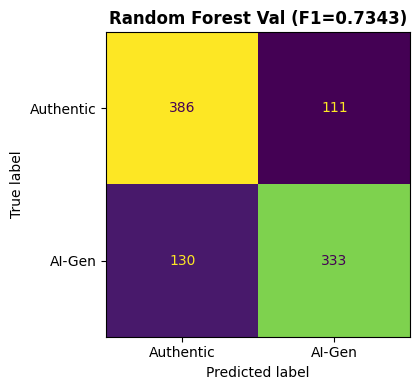

In [ ]:
rf_tr_idx, rf_val_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.20,
    stratify=y_train, random_state=SEED
)

sc_rf    = StandardScaler()
X_rf_tr  = sc_rf.fit_transform(X_hand_train[rf_tr_idx])
X_rf_val = sc_rf.transform(X_hand_train[rf_val_idx])

RF_PARAMS = dict(n_estimators=400, max_depth=None, min_samples_leaf=2,
                 n_jobs=-1, random_state=SEED, class_weight='balanced')

clf_rf      = RandomForestClassifier(**RF_PARAMS)
clf_rf.fit(X_rf_tr, y_train[rf_tr_idx])
rf_prob_val = clf_rf.predict_proba(X_rf_val)[:, 1]
rf_cv_f1    = f1_score(y_train[rf_val_idx], (rf_prob_val >= 0.5).astype(int))

print(f"Random Forest Baseline (80/20 split) — val F1 : {rf_cv_f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_train[rf_val_idx], (rf_prob_val >= 0.5).astype(int)),
    display_labels=['Authentic', 'AI-Gen']
).plot(ax=ax, colorbar=False)
ax.set_title(f'Random Forest Val (F1={rf_cv_f1:.4f})', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. CNN — EfficientNetV2-M

In [ ]:
IMG_SIZE = 288
BATCH    = 16

train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3))
])
val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tta_transforms = [
    val_tf,
    T.Compose([T.ToPILImage(), T.Resize((IMG_SIZE, IMG_SIZE)),
               T.RandomHorizontalFlip(p=1.0), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.ToPILImage(), T.Resize((IMG_SIZE, IMG_SIZE)),
               T.RandomRotation((10, 10)), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.ToPILImage(), T.Resize((IMG_SIZE, IMG_SIZE)),
               T.RandomRotation((-10, -10)), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.ToPILImage(), T.Resize((IMG_SIZE+20, IMG_SIZE+20)),
               T.CenterCrop(IMG_SIZE), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
]


class ImageDataset(Dataset):
    def __init__(self, df, transform, has_label=True):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.has_label = has_label

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['path'])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(img)
        return (img, int(row['label'])) if self.has_label else img


def mixup_data(x, y, alpha=0.3):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


class LabelSmoothBCE(nn.Module):
    def __init__(self, eps=0.05):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.eps) + 0.5 * self.eps
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)


class EffNetV2Classifier(nn.Module):
    def __init__(self, model_name='tf_efficientnetv2_m',
                 dropout1=0.4, dropout2=0.3, hidden=512):
        super().__init__()
        self.backbone   = timm.create_model(model_name, pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout1),
            nn.Linear(self.backbone.num_features, hidden),
            nn.GELU(),
            nn.Dropout(dropout2),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))


print(f"EfficientNetV2-M | img={IMG_SIZE}x{IMG_SIZE} | batch={BATCH}")
_tmp = EffNetV2Classifier().to(DEVICE)
print(f"Params : {sum(p.numel() for p in _tmp.parameters())/1e6:.1f}M")
del _tmp
if torch.cuda.is_available(): torch.cuda.empty_cache()

EfficientNetV2-M | img=288x288 | batch=16


model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

Params : 53.5M


## 7. CNN Training Helper (Two-Phase + MixUp)

In [ ]:
def train_one_cnn(tr_df, val_df, epochs=20, patience=4, seed=SEED,
                  mixup_alpha=0.3, use_mixup=True):
    """
    Two-phase training with MixUp and label smoothing.
    Phase 1: head warm-up (5 epochs, backbone frozen).
    Phase 2: full fine-tune with early stopping on val F1.
    Returns (model, history, best_val_f1).
    """
    torch.manual_seed(seed)
    tr_loader  = DataLoader(ImageDataset(tr_df,  train_tf),
                            batch_size=BATCH, shuffle=True,
                            num_workers=2, pin_memory=True)
    val_loader = DataLoader(ImageDataset(val_df, val_tf),
                            batch_size=BATCH, shuffle=False,
                            num_workers=2, pin_memory=True)

    model     = EffNetV2Classifier().to(DEVICE)
    criterion = LabelSmoothBCE(eps=0.05)

    def run_train_epoch(loader, optimizer, scheduler=None, do_mixup=False):
        model.train()
        total_loss = 0.0
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.float().to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            if do_mixup:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
                out  = model(imgs)
                loss = mixup_criterion(criterion, out, y_a, y_b, lam)
            else:
                out  = model(imgs)
                loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
        if scheduler is not None: scheduler.step()
        return total_loss / len(loader.dataset)

    def run_val_epoch(loader):
        model.eval()
        probs_out, trues_out = [], []
        with torch.no_grad():
            for imgs, labels in loader:
                out = model(imgs.to(DEVICE))
                probs_out.extend(torch.sigmoid(out).cpu().squeeze(1).tolist())
                trues_out.extend(labels.tolist())
        return np.array(probs_out), np.array(trues_out)

    history = {'train_loss': [], 'val_f1': []}
    best_f1, best_state, no_improve = 0.0, None, 0

    # Phase 1: head warm-up
    print("  Phase 1: head warm-up (5 epochs, backbone frozen)")
    for p in model.backbone.parameters(): p.requires_grad = False
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
    sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=5)
    for ep in range(5):
        tr_loss = run_train_epoch(tr_loader, opt1, sch1, do_mixup=False)
        vp, vt  = run_val_epoch(val_loader)
        val_f1  = f1_score(vt, (vp >= 0.5).astype(int))
        history['train_loss'].append(tr_loss)
        history['val_f1'].append(val_f1)
        print(f"    Ep {ep+1:2d}  loss={tr_loss:.4f}  val_F1={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())

    # Phase 2: full fine-tune
    phase2_ep = epochs - 5
    print(f"  Phase 2: full fine-tune (max {phase2_ep} ep, patience={patience}, "
          f"MixUp={'on' if use_mixup else 'off'})")
    model.load_state_dict(best_state)
    for p in model.parameters(): p.requires_grad = True
    opt2 = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_ep)
    for ep in range(phase2_ep):
        tr_loss = run_train_epoch(tr_loader, opt2, sch2, do_mixup=use_mixup)
        vp, vt  = run_val_epoch(val_loader)
        val_f1  = f1_score(vt, (vp >= 0.5).astype(int))
        history['train_loss'].append(tr_loss)
        history['val_f1'].append(val_f1)
        print(f"    Ep {ep+6:2d}  loss={tr_loss:.4f}  val_F1={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    Early stop at epoch {ep+6}")
                break

    model.load_state_dict(best_state)
    return model, history, best_f1


def get_probs(model, df, has_label=True, use_tta=False):
    """Sigmoid probabilities with optional TTA."""
    transforms_to_use = tta_transforms if use_tta else [val_tf]
    all_probs = []
    model.eval()
    for tf in transforms_to_use:
        loader = DataLoader(ImageDataset(df, tf, has_label=has_label),
                            batch_size=BATCH, shuffle=False,
                            num_workers=2, pin_memory=True)
        probs = []
        with torch.no_grad():
            for batch in loader:
                imgs = batch[0] if has_label else batch
                out  = model(imgs.to(DEVICE))
                probs.extend(torch.sigmoid(out).cpu().squeeze(1).tolist())
        all_probs.append(np.array(probs))
    return np.mean(all_probs, axis=0)


print("CNN helpers ready.")

CNN helpers ready.


## 8. Training CNN

In [ ]:
cnn_tr_idx, cnn_val_idx = train_test_split(
    np.arange(len(train_df_valid)),
    test_size=0.20, stratify=y_train, random_state=SEED
)
cnn_tr_df  = train_df_valid.iloc[cnn_tr_idx].reset_index(drop=True)
cnn_val_df = train_df_valid.iloc[cnn_val_idx].reset_index(drop=True)

MAIN_CNN_CKPT    = os.path.join(CKPT_DIR, "main_cnn.pt")
MAIN_HIST_CKPT   = os.path.join(CKPT_DIR, "main_cnn_history.npy")

print(f"CNN train : {len(cnn_tr_df):,}  |  CNN val : {len(cnn_val_df):,}")

if os.path.exists(MAIN_CNN_CKPT):
    # ── RESUME: load saved weights ────────────────────────────────────────
    print(f"\n[CHECKPOINT] Main CNN found at {MAIN_CNN_CKPT} — loading, skipping training.")
    model_cnn = EffNetV2Classifier().to(DEVICE)
    model_cnn.load_state_dict(torch.load(MAIN_CNN_CKPT, map_location=DEVICE))
    cnn_history = np.load(MAIN_HIST_CKPT, allow_pickle=True).item()
    best_f1_cnn = max(cnn_history['val_f1'])
    print(f"Loaded main CNN  |  best val F1 = {best_f1_cnn:.4f}")
else:
    # ── TRAIN from scratch ────────────────────────────────────────────────
    print("\nTraining main EfficientNetV2-M ...")
    model_cnn, cnn_history, best_f1_cnn = train_one_cnn(
        cnn_tr_df, cnn_val_df, epochs=20, patience=4
    )
    # Save immediately after training completes
    torch.save(model_cnn.state_dict(), MAIN_CNN_CKPT)
    np.save(MAIN_HIST_CKPT, cnn_history)
    print(f"\n[CHECKPOINT] Main CNN saved → {MAIN_CNN_CKPT}")
    print(f"Best val F1 (main CNN) : {best_f1_cnn:.4f}")

CNN train : 3,840  |  CNN val : 960

[CHECKPOINT] Main CNN found at /content/drive/MyDrive/DCU 2026 ML challenge/checkpoints/main_cnn.pt — loading, skipping training.


Loaded main CNN  |  best val F1 = 0.8740


## 9. CNN OOF Probabilities

In [ ]:
# ── 20% val: clean probs from main CNN (TTA) ────────────────────────────
VAL_PROBS_CKPT = os.path.join(CKPT_DIR, "cnn_probs_val.npy")

if os.path.exists(VAL_PROBS_CKPT):
    cnn_probs_val = np.load(VAL_PROBS_CKPT)
    print(f"[CHECKPOINT] Val probs loaded from {VAL_PROBS_CKPT}")
else:
    cnn_probs_val = get_probs(model_cnn, cnn_val_df, has_label=True, use_tta=True)
    np.save(VAL_PROBS_CKPT, cnn_probs_val)
    print(f"[CHECKPOINT] Val probs saved → {VAL_PROBS_CKPT}")

print(f"val 20% F1 (TTA) : "
      f"{f1_score(y_train[cnn_val_idx], (cnn_probs_val>=0.5).astype(int)):.4f}")

# ── Free main CNN from VRAM before OOF loop ──────────────────────────────
# This is critical — keeps ~7 GB free for each fold CNN clone.
model_cnn.cpu()
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()
print("Main CNN moved to CPU — VRAM cleared for OOF loop.")

# ── 80% train: 5-fold OOF with per-fold checkpointing ────────────────────
print("\nGenerating OOF CNN probs for train 80% (5-fold) ...")
cnn_probs_tr = np.zeros(len(cnn_tr_idx))
y_tr         = y_train[cnn_tr_idx]
skf_oof      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (fi_tr, fi_val) in enumerate(skf_oof.split(np.arange(len(cnn_tr_df)), y_tr)):
    FOLD_CKPT = os.path.join(CKPT_DIR, f"oof_fold_{fold}.npy")

    if os.path.exists(FOLD_CKPT):
        # ── Already done: load saved probs, skip training ─────────────────
        fold_probs = np.load(FOLD_CKPT)
        cnn_probs_tr[fi_val] = fold_probs
        fold_f1 = f1_score(y_tr[fi_val], (fold_probs >= 0.5).astype(int))
        print(f"  Fold {fold+1}/5  [CHECKPOINT loaded]  OOF F1={fold_f1:.4f}  "
              f"(skipped training)")
    else:
        # ── Not done yet: train fold CNN ──────────────────────────────────
        print(f"  Fold {fold+1}/5  [training] ...")
        f_model, _, _ = train_one_cnn(
            cnn_tr_df.iloc[fi_tr].reset_index(drop=True),
            cnn_tr_df.iloc[fi_val].reset_index(drop=True),
            epochs=16, patience=3, seed=SEED + fold
        )
        fold_probs = get_probs(
            f_model,
            cnn_tr_df.iloc[fi_val].reset_index(drop=True),
            has_label=True, use_tta=False
        )
        # Save fold probs to Drive immediately
        np.save(FOLD_CKPT, fold_probs)
        cnn_probs_tr[fi_val] = fold_probs
        fold_f1 = f1_score(y_tr[fi_val], (fold_probs >= 0.5).astype(int))
        print(f"  Fold {fold+1}/5  [CHECKPOINT saved]   OOF F1={fold_f1:.4f}")

        del f_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()

print(f"\ntrain 80% OOF F1 : {f1_score(y_tr, (cnn_probs_tr>=0.5).astype(int)):.4f}")

# Reconstruct full-train prob array in original order
cnn_prob_train = np.zeros(len(train_df_valid))
cnn_prob_train[cnn_tr_idx]  = cnn_probs_tr
cnn_prob_train[cnn_val_idx] = cnn_probs_val
print(f"Full-train CNN prob array : {cnn_prob_train.shape}")

# Reload main CNN to GPU for test-time TTA inference later
print("\nReloading main CNN to GPU for test inference ...")
model_cnn = EffNetV2Classifier().to(DEVICE)
model_cnn.load_state_dict(torch.load(MAIN_CNN_CKPT, map_location=DEVICE))
model_cnn.eval()
print("Main CNN ready.")

[CHECKPOINT] Val probs loaded from /content/drive/MyDrive/DCU 2026 ML challenge/checkpoints/cnn_probs_val.npy
val 20% F1 (TTA) : 0.8768
Main CNN moved to CPU — VRAM cleared for OOF loop.

Generating OOF CNN probs for train 80% (5-fold) ...
  Fold 1/5  [CHECKPOINT loaded]  OOF F1=0.8208  (skipped training)
  Fold 2/5  [training] ...
  Phase 1: head warm-up (5 epochs, backbone frozen)
    Ep  1  loss=0.6196  val_F1=0.7538
    Ep  2  loss=0.5712  val_F1=0.7330
    Ep  3  loss=0.5733  val_F1=0.7540
    Ep  4  loss=0.5412  val_F1=0.7481
    Ep  5  loss=0.5377  val_F1=0.7487
  Phase 2: full fine-tune (max 11 ep, patience=3, MixUp=on)
    Ep  6  loss=0.5595  val_F1=0.7858
    Ep  7  loss=0.5016  val_F1=0.8175
    Ep  8  loss=0.4557  val_F1=0.8316
    Ep  9  loss=0.4497  val_F1=0.8325
    Ep 10  loss=0.4167  val_F1=0.8477
    Ep 11  loss=0.3933  val_F1=0.8272
    Ep 12  loss=0.3674  val_F1=0.8159
    Ep 13  loss=0.3910  val_F1=0.8370
    Early stop at epoch 13
  Fold 2/5  [CHECKPOINT saved]   

## 10. XGBoost + LightGBM Ensemble

In [ ]:
oof_probs_xgb     = np.zeros(len(y_train))
oof_probs_lgb     = np.zeros(len(y_train))
fold_f1s_xgb      = []
fold_f1s_lgb      = []
hybrid_xgb_models = []
hybrid_lgb_models = []

XGB_PARAMS = dict(
    n_estimators=800, max_depth=5, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.75,
    reg_alpha=0.2, reg_lambda=2.0, min_child_weight=3,
    eval_metric='logloss', random_state=SEED,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
LGB_PARAMS = dict(
    n_estimators=1000, max_depth=6, learning_rate=0.025,
    num_leaves=63, subsample=0.85, colsample_bytree=0.75,
    reg_alpha=0.1, reg_lambda=1.5, min_child_samples=20,
    device='gpu' if torch.cuda.is_available() else 'cpu',
    random_state=SEED, verbose=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("Hybrid XGBoost + LightGBM (5-fold CV):")
for fold, (tr_i, val_i) in enumerate(skf.split(X_hand_train, y_train)):
    sc      = StandardScaler()
    X_tr_h  = sc.fit_transform(X_hand_train[tr_i])
    X_val_h = sc.transform(X_hand_train[val_i])

    X_tr  = np.hstack([cnn_prob_train[tr_i].reshape(-1, 1),  X_tr_h])
    X_val = np.hstack([cnn_prob_train[val_i].reshape(-1, 1), X_val_h])

    clf_x = xgb.XGBClassifier(**XGB_PARAMS)
    clf_x.fit(X_tr, y_train[tr_i],
              eval_set=[(X_val, y_train[val_i])], verbose=False)
    p_x = clf_x.predict_proba(X_val)[:, 1]
    f_x = f1_score(y_train[val_i], (p_x >= 0.5).astype(int))
    oof_probs_xgb[val_i] = p_x
    fold_f1s_xgb.append(f_x)
    hybrid_xgb_models.append((clf_x, sc))

    clf_l = lgb.LGBMClassifier(**LGB_PARAMS)
    clf_l.fit(X_tr, y_train[tr_i],
              eval_set=[(X_val, y_train[val_i])],
              callbacks=[lgb.early_stopping(60, verbose=False),
                         lgb.log_evaluation(-1)])
    p_l = clf_l.predict_proba(X_val)[:, 1]
    f_l = f1_score(y_train[val_i], (p_l >= 0.5).astype(int))
    oof_probs_lgb[val_i] = p_l
    fold_f1s_lgb.append(f_l)
    hybrid_lgb_models.append((clf_l, sc))

    print(f"  Fold {fold+1}/5  XGB={f_x:.4f}  LGB={f_l:.4f}")

oof_probs_hybrid = 0.5 * oof_probs_xgb + 0.5 * oof_probs_lgb
print(f"\nXGB  CV F1  : {np.mean(fold_f1s_xgb):.4f} +/- {np.std(fold_f1s_xgb):.4f}")
print(f"LGB  CV F1  : {np.mean(fold_f1s_lgb):.4f} +/- {np.std(fold_f1s_lgb):.4f}")
print(f"Ensemble F1 : {f1_score(y_train, (oof_probs_hybrid>=0.5).astype(int)):.4f}")

Hybrid XGBoost + LightGBM (5-fold CV):
  Fold 1/5  XGB=0.8754  LGB=0.8786
  Fold 2/5  XGB=0.8930  LGB=0.8886
  Fold 3/5  XGB=0.9109  LGB=0.9029
  Fold 4/5  XGB=0.8681  LGB=0.8575
  Fold 5/5  XGB=0.8738  LGB=0.8666

XGB  CV F1  : 0.8842 +/- 0.0157
LGB  CV F1  : 0.8789 +/- 0.0160
Ensemble F1 : 0.8806


## 11. Threshold Optimisation on OOF Probabilities

Youden J  → thresh=0.384  F1=0.8860
Grid      → thresh=0.385  F1=0.8859
Selected  → thresh=0.384


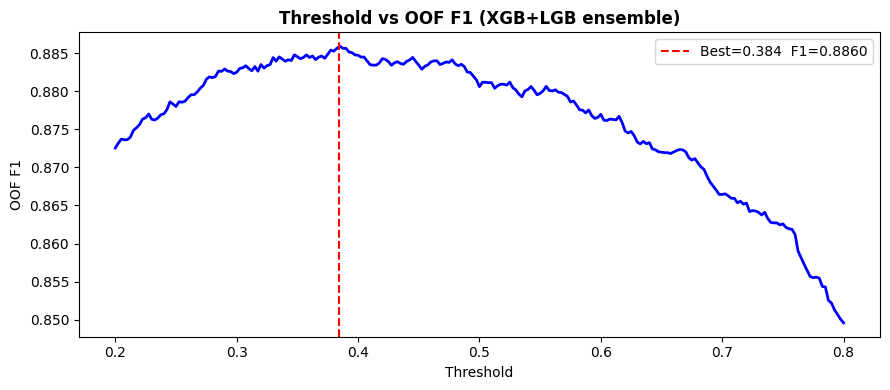

In [ ]:
fpr_oof, tpr_oof, thresh_roc = roc_curve(y_train, oof_probs_hybrid)
j_scores      = tpr_oof - fpr_oof
best_thresh_j = float(thresh_roc[np.argmax(j_scores)])
f1_j          = f1_score(y_train, (oof_probs_hybrid >= best_thresh_j).astype(int))

thresholds    = np.linspace(0.20, 0.80, 241)
f1_grid       = [f1_score(y_train, (oof_probs_hybrid >= t).astype(int)) for t in thresholds]
best_thresh_g = float(thresholds[np.argmax(f1_grid)])
f1_g          = max(f1_grid)

best_thresh = best_thresh_j if f1_j >= f1_g else best_thresh_g
print(f"Youden J  → thresh={best_thresh_j:.3f}  F1={f1_j:.4f}")
print(f"Grid      → thresh={best_thresh_g:.3f}  F1={f1_g:.4f}")
print(f"Selected  → thresh={best_thresh:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_grid, 'b-', lw=2)
ax.axvline(best_thresh, color='red', linestyle='--',
           label=f'Best={best_thresh:.3f}  F1={max(f1_j, f1_g):.4f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('OOF F1')
ax.set_title('Threshold vs OOF F1 (XGB+LGB ensemble)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 12. Full Evaluation & Visualisations

HYBRID MODEL — OOF EVALUATION (zero leakage)
              precision    recall  f1-score   support

   Authentic       0.90      0.88      0.89      2485
AI-Generated       0.87      0.90      0.89      2315

    accuracy                           0.89      4800
   macro avg       0.89      0.89      0.89      4800
weighted avg       0.89      0.89      0.89      4800

F1        : 0.8860
Precision : 0.8730
Recall    : 0.8994
ROC AUC   : 0.9563


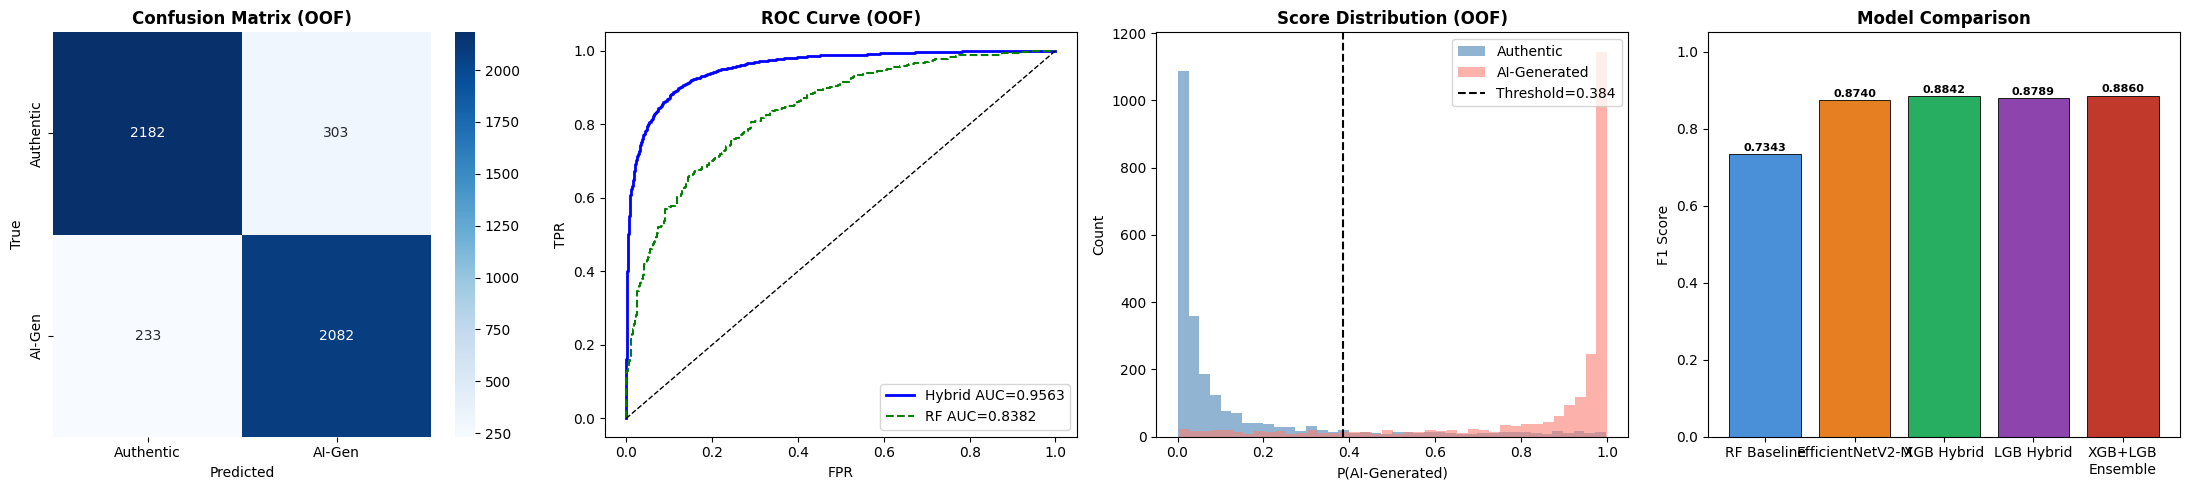

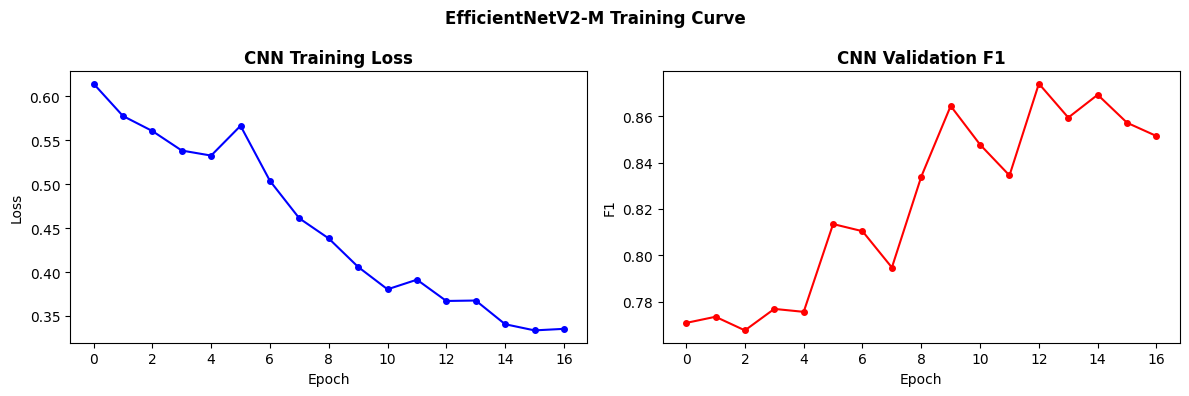

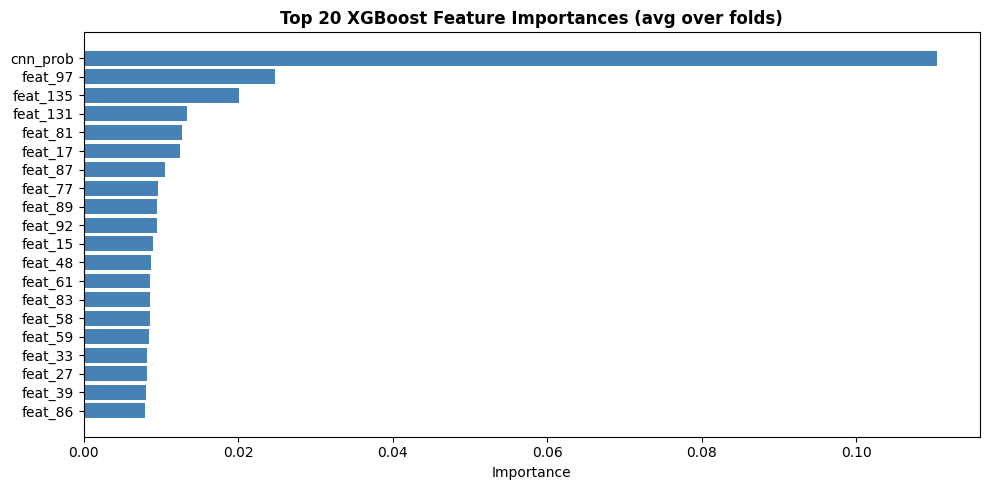

In [ ]:
final_preds = (oof_probs_hybrid >= best_thresh).astype(int)
f1_final    = f1_score(y_train, final_preds)
prec        = precision_score(y_train, final_preds)
rec         = recall_score(y_train, final_preds)
auc         = roc_auc_score(y_train, oof_probs_hybrid)

print("=" * 55)
print("HYBRID MODEL — OOF EVALUATION (zero leakage)")
print("=" * 55)
print(classification_report(y_train, final_preds,
                             target_names=['Authentic', 'AI-Generated']))
print(f"F1        : {f1_final:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"ROC AUC   : {auc:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

cm = confusion_matrix(y_train, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic','AI-Gen'],
            yticklabels=['Authentic','AI-Gen'], ax=axes[0])
axes[0].set_title('Confusion Matrix (OOF)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_train, oof_probs_hybrid)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'Hybrid AUC={auc:.4f}')
rf_auc = roc_auc_score(y_train[rf_val_idx], rf_prob_val)
fpr_rf, tpr_rf, _ = roc_curve(y_train[rf_val_idx], rf_prob_val)
axes[1].plot(fpr_rf, tpr_rf, 'g--', lw=1.5, label=f'RF AUC={rf_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve (OOF)', fontweight='bold'); axes[1].legend()

axes[2].hist(oof_probs_hybrid[y_train==0], bins=40, alpha=0.6,
             label='Authentic', color='steelblue')
axes[2].hist(oof_probs_hybrid[y_train==1], bins=40, alpha=0.6,
             label='AI-Generated', color='salmon')
axes[2].axvline(best_thresh, color='black', linestyle='--',
                label=f'Threshold={best_thresh:.3f}')
axes[2].set_xlabel('P(AI-Generated)'); axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution (OOF)', fontweight='bold')
axes[2].legend()

model_names = ['RF Baseline', 'EfficientNetV2-M', 'XGB Hybrid',
               'LGB Hybrid', 'XGB+LGB\nEnsemble']
f1_values   = [rf_cv_f1, best_f1_cnn,
               np.mean(fold_f1s_xgb), np.mean(fold_f1s_lgb), f1_final]
colours     = ['#4a90d9','#e67e22','#27ae60','#8e44ad','#c0392b']
bars = axes[3].bar(model_names, f1_values, color=colours,
                   edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, f1_values):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
axes[3].set_ylim(0, 1.05); axes[3].set_ylabel('F1 Score')
axes[3].set_title('Model Comparison', fontweight='bold')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history['train_loss'], 'b-o', markersize=4)
axes[0].set_title('CNN Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].plot(cnn_history['val_f1'], 'r-o', markersize=4)
axes[1].set_title('CNN Validation F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
plt.suptitle('EfficientNetV2-M Training Curve', fontweight='bold')
plt.tight_layout(); plt.show()

feat_names  = ['cnn_prob'] + [f'feat_{i}' for i in range(X_hand_train.shape[1])]
importances = np.mean([cx.feature_importances_ for cx, _ in hybrid_xgb_models], axis=0)
top_k   = 20
top_idx = np.argsort(importances)[-top_k:][::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([feat_names[i] for i in top_idx[::-1]], importances[top_idx[::-1]], color='steelblue')
ax.set_title(f'Top {top_k} XGBoost Feature Importances (avg over folds)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 13. Test Inference with TTA & Submission

In [ ]:
print("CNN probabilities for test set (with TTA) ...")
cnn_prob_test = get_probs(model_cnn, test_df_valid, has_label=False, use_tta=True)

test_p_xgb, test_p_lgb = [], []
for (cx, sc), (cl, _) in zip(hybrid_xgb_models, hybrid_lgb_models):
    X_t = np.hstack([cnn_prob_test.reshape(-1, 1), sc.transform(X_hand_test)])
    test_p_xgb.append(cx.predict_proba(X_t)[:, 1])
    test_p_lgb.append(cl.predict_proba(X_t)[:, 1])

test_probs = 0.5 * np.mean(test_p_xgb, axis=0) + 0.5 * np.mean(test_p_lgb, axis=0)
test_preds = (test_probs >= best_thresh).astype(int)

print("\nTest prediction distribution:")
for v, c in zip(*np.unique(test_preds, return_counts=True)):
    print(f"  {'AI-Generated' if v else 'Authentic':15s}: {c:4d}  ({100*c/len(test_preds):.1f}%)")

submission = pd.DataFrame({
    'image_id':   test_df_valid['image_id'].values,
    'prediction': test_preds
})
missing_ids = [i for i in test_df['image_id'].values
               if i not in test_df_valid['image_id'].values]
if missing_ids:
    mode_p     = int(np.round(np.mean(test_preds)))
    submission = pd.concat([
        submission,
        pd.DataFrame({'image_id': missing_ids, 'prediction': mode_p})
    ], ignore_index=True)
    print(f"Filled {len(missing_ids)} unreadable image(s) with pred={mode_p}")

submission = (submission.set_index('image_id')
                        .loc[test_df['image_id']]
                        .reset_index())

out_path = os.path.join(CHALLENGE_DIR, 'submission.csv')
submission.to_csv(out_path, index=False)
print(f"\nSaved {len(submission):,} rows → {out_path}")
print(submission.head(10))

CNN probabilities for test set (with TTA) ...

Test prediction distribution:
  Authentic      : 1064  (51.7%)
  AI-Generated   :  994  (48.3%)

Saved 2,058 rows → /content/drive/MyDrive/DCU 2026 ML challenge/submission.csv
                                   image_id  prediction
0  3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg           0
1  2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg           0
2  01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg           0
3  ac784910-b461-498d-b3a8-50b1e4116b11.jpg           0
4  6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg           0
5  73b2089b-34a5-49de-a98b-2325512322f1.jpg           0
6  8bb3958b-3487-4ad4-86cc-5c391e3bd9a4.jpg           1
7  23a0595f-7b9e-47ce-ae12-07a83a00c189.jpg           0
8  32e05946-83ff-4780-9090-4ad99ccd4134.jpg           0
9  674a7ded-31e4-41b1-a7cf-4a6c04fd4af1.jpg           1


## 14. Final Summary

In [ ]:
print("=" * 65)
print("FINAL SUMMARY — EfficientNetV2-M + XGB + LGB Hybrid")
print("=" * 65)
print(f"Random Forest baseline val F1 : {rf_cv_f1:.4f}")
print(f"EfficientNetV2-M val F1 (TTA) : {best_f1_cnn:.4f}")
print(f"XGB hybrid CV F1              : {np.mean(fold_f1s_xgb):.4f} +/- {np.std(fold_f1s_xgb):.4f}")
print(f"LGB hybrid CV F1              : {np.mean(fold_f1s_lgb):.4f} +/- {np.std(fold_f1s_lgb):.4f}")
print(f"XGB+LGB ensemble OOF F1       : {f1_final:.4f}")
print(f"ROC AUC                       : {auc:.4f}")
print(f"Decision threshold            : {best_thresh:.3f}")
print(f"Test submission rows          : {len(submission):,}")
print(f"Submission file               : submission.csv")

print("\n--- Checkpoint Files on Drive ---")
for fname in sorted(os.listdir(CKPT_DIR)):
    fpath = os.path.join(CKPT_DIR, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:35s}  {size:.1f} MB")

FINAL SUMMARY — EfficientNetV2-M + XGB + LGB Hybrid
Random Forest baseline val F1 : 0.7343
EfficientNetV2-M val F1 (TTA) : 0.8740
XGB hybrid CV F1              : 0.8842 +/- 0.0157
LGB hybrid CV F1              : 0.8789 +/- 0.0160
XGB+LGB ensemble OOF F1       : 0.8860
ROC AUC                       : 0.9563
Decision threshold            : 0.384
Test submission rows          : 2,058
Submission file               : submission.csv

--- Checkpoint Files on Drive ---
  X_hand_test.npy                      1.1 MB
  X_hand_train.npy                     2.7 MB
  cnn_probs_val.npy                    0.0 MB
  main_cnn.pt                          215.6 MB
  main_cnn_history.npy                 0.0 MB
  oof_fold_0.npy                       0.0 MB
  oof_fold_1.npy                       0.0 MB
  oof_fold_2.npy                       0.0 MB
  oof_fold_3.npy                       0.0 MB
  oof_fold_4.npy                       0.0 MB
